# Bayesian updating of Portugal's 2025 GDP after the revised population estimate

INE revised Portugal's resident population sharply upward for 2025. A *denominator-only*
reading says GDP per capita must fall (same GDP, more people). This notebook treats
population, GDP, GDP per capita and the GDP-per-capita-in-PPS index as **uncertain
quantities to be updated**, and asks the substantive question: if the extra residents are
largely **working migrants**, how much of the revision should flow into **output** too?

What this version does:

1. fetches the longest World Bank series and patches the revised 2025 INE population;
2. estimates a posterior for population, then **GDP in euros** (so the nominal-growth
   identity holds and euro/dollar moves do not contaminate the result);
3. **back-tests** the GDP model out-of-sample before trusting its forward estimate;
4. runs **labour-channel scenarios with uncertainty** on how many extra residents work;
5. carries everything through to the **GDP-per-capita-in-PPS** index that the public
   argument is actually about.

Everything is descriptive of *assumptions*: the output is a map of plausible outcomes, not
a single corrected number.

## 1. Imports, project path, and a display helper

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from pt_gdp_bayes.bayes import summarize_samples
from pt_gdp_bayes.data_sources import (
    DataDownloadError,
    fetch_world_bank_panel,
    get_known_value,
    load_known_observations,
    patch_manual_observation,
)
from pt_gdp_bayes.model import (
    backtest_gdp_model,
    estimate_gdp_posterior_samples,
    estimate_population_posterior_samples,
    estimate_pps_index_samples,
    simulate_labour_channel_samples,
)
from pt_gdp_bayes.plotting import plot_posterior_histogram

pd.set_option("display.max_columns", 100)


def summarise(samples, *, scale=1.0, unit="", decimals=2, label="value"):
    """Format a posterior summary (mean/median/sd/90% interval) as a tidy table."""
    stats = summarize_samples(samples)
    order = ["mean", "median", "sd", "q5", "q95"]
    return pd.DataFrame({label: {k: f"{stats[k] / scale:,.{decimals}f}{unit}" for k in order}})

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## 2. Manual official anchors

A few values are pinned by hand from INE press releases and the article under examination
(see `data/known_observations.csv` and `data/source_catalog.json` for the exact sources).
These are **input observations**, not conclusions.

In [2]:
known_observations = load_known_observations(PROJECT_ROOT / "data" / "known_observations.csv")
known_observations[["variable", "year", "value", "unit", "source"]]

,variable,year,value,unit,source
0,resident_population,2025,1.142403e+07,persons,INE Press Release 771843617
1,foreign_residents,2025,1.597539e+06,persons,INE Press Release 771843617
2,foreign_resident_share,2025,1.400000e-01,share,INE Press Release 771843617
3,real_gdp_growth,2025,1.900000e-02,log_approx_or_decimal,INE Press Release 706214887
4,preliminary_gdp_pc_pps_index,2025,8.130000e+01,EU27_2025_100,User supplied article citing European Commissi...
5,population_correction_factor,2025,1.056000e+00,ratio,User supplied article calculations
6,article_corrected_gdp_pc_pps_index,2025,7.700000e+01,EU27_2025_100,User supplied article calculations


## 3. Long historical series (World Bank)

We pull the longest available series. Note both a **current-USD** GDP series (for context)
and a **current-EUR** series (`NY.GDP.MKTP.CN`) — the modelling uses **euros** so that
"nominal GDP growth = real growth + GDP-deflator growth" actually holds. Modelling GDP in
USD would fold the euro/dollar exchange rate into growth, which the local deflator does not
describe.

In [3]:
WORLD_BANK_INDICATORS = {
    "population": "SP.POP.TOTL",
    "gdp_current_eur": "NY.GDP.MKTP.CN",     # current local currency (EUR) - used for modelling
    "gdp_current_usd": "NY.GDP.MKTP.CD",     # current USD - context only
    "gdp_constant_lcu": "NY.GDP.MKTP.KN",
    "real_gdp_growth_pct": "NY.GDP.MKTP.KD.ZG",
    "gdp_deflator_pct": "NY.GDP.DEFL.KD.ZG",
    "unemployment_pct": "SL.UEM.TOTL.ZS",
    "labor_force": "SL.TLF.TOTL.IN",
}

try:
    panel = fetch_world_bank_panel("PRT", WORLD_BANK_INDICATORS, start_year=1960, end_year=2025)
except DataDownloadError as exc:
    raise RuntimeError(
        "Could not download the World Bank data. Run this notebook on a machine with "
        "internet access; the model is complete but needs to reach external APIs."
    ) from exc

panel.tail()

,year,population,gdp_current_eur,gdp_current_usd,gdp_constant_lcu,real_gdp_growth_pct,gdp_deflator_pct,unemployment_pct,labor_force
61,2021,10361831.0,2.164937e+11,2.560559e+11,2.122076e+11,5.558757,2.019777,6.712,5114630.0
62,2022,10434332.0,2.439571e+11,2.568987e+11,2.270321e+11,6.985841,5.327500,6.138,5245513.0
63,2023,10578174.0,2.703526e+11,2.923238e+11,2.340701e+11,3.099979,7.487648,6.498,5395411.0
64,2024,10694681.0,2.894280e+11,3.132712e+11,2.390784e+11,2.139672,4.813077,6.500,5450166.0
65,2025,NaN,NaN,NaN,NaN,NaN,NaN,6.164,5419014.0


## 4. Patch the revised 2025 INE population estimate

International APIs lag national revisions, so we patch the 2025 resident-population row with
the revised INE figure.

In [4]:
revised_population_2025 = get_known_value(known_observations, "resident_population", 2025)
real_gdp_growth_2025 = get_known_value(known_observations, "real_gdp_growth", 2025)
preliminary_pps_index = get_known_value(known_observations, "preliminary_gdp_pc_pps_index", 2025)
population_correction_factor = get_known_value(known_observations, "population_correction_factor", 2025)

panel = patch_manual_observation(
    panel, year=2025, column="population", value=revised_population_2025,
    note="Patched with revised INE 2025 resident population estimate",
)
panel.loc[panel["year"].between(2020, 2025),
          ["year", "population", "gdp_current_eur", "gdp_deflator_pct", "manual_patch_notes"]]

,year,population,gdp_current_eur,gdp_deflator_pct,manual_patch_notes
60,2020,10297081.0,2.010327e+11,2.103143,
61,2021,10361831.0,2.164937e+11,2.019777,
62,2022,10434332.0,2.439571e+11,5.327500,
63,2023,10578174.0,2.703526e+11,7.487648,
64,2024,10694681.0,2.894280e+11,4.813077,
65,2025,11424031.0,NaN,NaN,Patched with revised INE 2025 resident populat...


## 5. Posterior population estimate

A Bayesian AR(1) on log population growth (fitted to pre-2025 data) gives the prior; the
revised INE figure enters as a noisy observation. The observation SD is kept **small
(~0.15%)** on purpose. The pre-revision World Bank trajectory extrapolates to only ~10.7M,
but that series is exactly what the revision **supersedes** — so the posterior should anchor
to the official 11.42M, not be dragged back toward the stale extrapolation. (Widening the SD
pulls the posterior visibly below the official figure, which would be wrong here.) The AR(1)
prior's real job is to characterise population **growth**, which feeds the GDP regression
below. The posterior therefore sits just under 11.42M, the small gap being honest residual
uncertainty around a figure that will itself be revised again.

In [5]:
population_result = estimate_population_posterior_samples(
    panel, target_year=2025, population_col="population",
    observed_population=revised_population_2025,
    observation_relative_sd=0.0015, n_samples=20_000, random_seed=7,
)
summarise(population_result.samples, scale=1e6, unit="M", decimals=3, label="population_2025 (millions)")

,population_2025 (millions)
mean,11.398M
median,11.398M
sd,0.017M
q5,11.371M
q95,11.426M


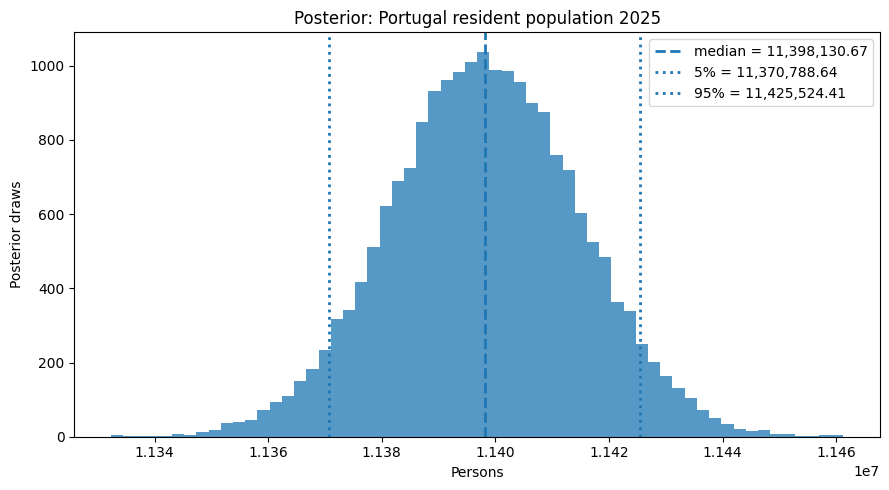

In [6]:
plot_posterior_histogram(population_result.samples,
                         title="Posterior: Portugal resident population 2025",
                         xlabel="Persons")

## 6. Posterior GDP estimate (euros)

GDP growth is modelled in **euros** with a Bayesian regression on its own lag, population
growth (so the population revision feeds output), lagged population growth and deflator
growth, then combined with a direct signal from the known 2025 real-growth figure plus an
inferred deflator. GDP is therefore **not** held fixed when population is revised.

In [7]:
gdp_result = estimate_gdp_posterior_samples(
    panel, target_year=2025, population_samples=population_result.samples,
    gdp_col="gdp_current_eur", population_col="population", deflator_col="gdp_deflator_pct",
    known_real_gdp_growth=real_gdp_growth_2025, real_growth_observation_sd=0.003,
    n_samples=20_000, random_seed=11,
)
summarise(gdp_result.gdp_samples, scale=1e9, unit=" bn", decimals=1, label="GDP_2025 (billion EUR)")

,GDP_2025 (billion EUR)
mean,316.1 bn
median,315.9 bn
sd,13.1 bn
q5,294.7 bn
q95,338.3 bn


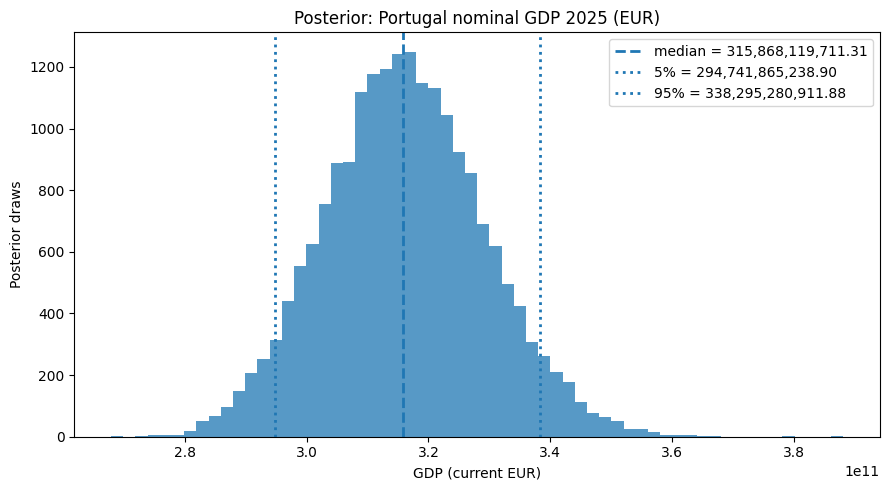

In [8]:
plot_posterior_histogram(gdp_result.gdp_samples,
                         title="Posterior: Portugal nominal GDP 2025 (EUR)",
                         xlabel="GDP (current EUR)")

## 7. Does the GDP model actually predict? An out-of-sample back-test

Before trusting the 2025 estimate, we check the model on years we already know. For each
hold-out year the model is **re-fitted on data before that year** and predicts nominal GDP
**without** the contemporaneous real-growth signal (no leakage). A trustworthy model keeps
the percentage error small and contains the realised value inside its 90% interval about
90% of the time.

In [9]:
backtest = backtest_gdp_model(
    panel, holdout_years=list(range(2010, 2024)),
    gdp_col="gdp_current_eur", credible_mass=0.90, n_samples=4_000,
)
coverage = backtest["in_interval"].mean()
mae = backtest["pct_error"].abs().mean()
print(f"Hold-out years: {len(backtest)} | 90% interval coverage: {coverage:.0%} "
      f"(target ~90%) | mean abs error: {mae:.1f}%")

bt_show = backtest.assign(
    actual=lambda d: (d["actual"] / 1e9).round(1),
    predicted_median=lambda d: (d["predicted_median"] / 1e9).round(1),
    q_low=lambda d: (d["q_low"] / 1e9).round(1),
    q_high=lambda d: (d["q_high"] / 1e9).round(1),
    pct_error=lambda d: d["pct_error"].round(1),
)[["year", "actual", "predicted_median", "q_low", "q_high", "pct_error", "in_interval"]]
bt_show

Hold-out years: 14 | 90% interval coverage: 79% (target ~90%) | mean abs error: 6.1%


,year,actual,predicted_median,q_low,q_high,pct_error,in_interval
0,2010,179.9,190.8,173.7,210.2,6.1,True
1,2011,176.3,197.4,179.9,216.9,11.9,False
2,2012,168.5,190.6,173.2,210.3,13.1,False
3,2013,170.7,180.1,163.2,199.1,5.5,True
4,2014,173.2,185.0,168.1,204.1,6.8,True
5,2015,179.4,187.4,170.2,206.7,4.4,True
6,2016,186.4,195.1,177.3,215.0,4.7,True
7,2017,195.5,202.6,184.3,223.2,3.6,True
8,2018,205.0,212.9,193.8,234.3,3.9,True
9,2019,214.5,223.1,203.1,245.3,4.0,True


**Reading this table.** `actual` and predictions are billion EUR. `pct_error` is the median
prediction's percentage error vs the realised value; `in_interval` is whether the realised
GDP fell inside the predicted 90% credible interval. Coverage near 90% and small errors mean
the model is reasonably calibrated; large gaps in crisis years (2011-2013) are expected,
since a smooth growth model cannot foresee shocks.

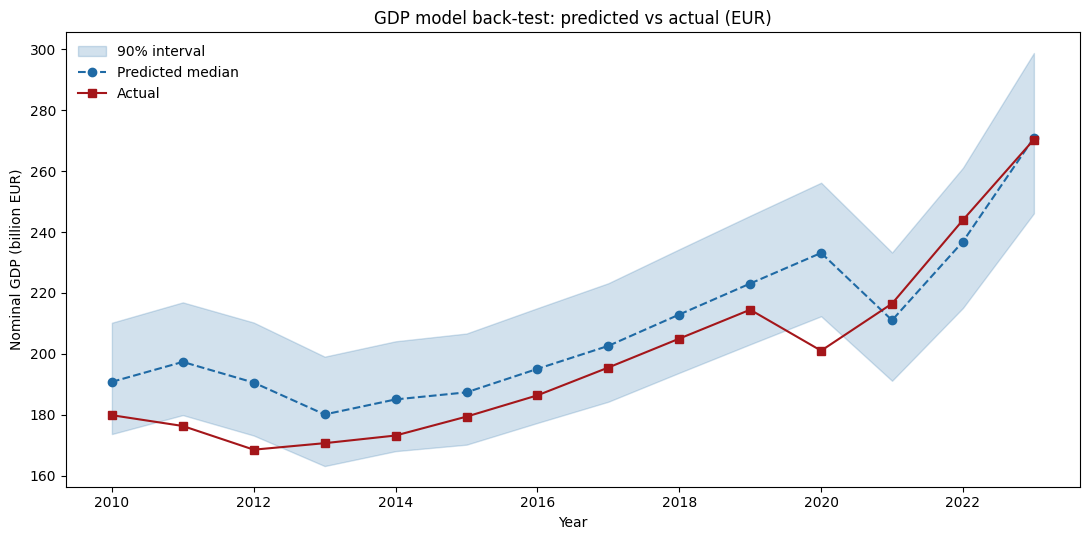

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(backtest["year"], backtest["q_low"] / 1e9, backtest["q_high"] / 1e9,
                alpha=0.2, color="#1f6aa5", label="90% interval")
ax.plot(backtest["year"], backtest["predicted_median"] / 1e9, "o--", color="#1f6aa5",
        label="Predicted median")
ax.plot(backtest["year"], backtest["actual"] / 1e9, "s-", color="#A4161A", label="Actual")
ax.set(title="GDP model back-test: predicted vs actual (EUR)", xlabel="Year",
       ylabel="Nominal GDP (billion EUR)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 8. Posterior GDP per capita (euros)

Dividing the GDP posterior by the population posterior, draw by draw, propagates both
uncertainties.

In [11]:
gdp_pc_samples = gdp_result.gdp_samples / population_result.samples
summarise(gdp_pc_samples, scale=1.0, unit=" EUR", decimals=0, label="GDP per capita 2025 (EUR)")

,GDP per capita 2025 (EUR)
mean,"27,733 EUR"
median,"27,714 EUR"
sd,"1,152 EUR"
q5,"25,860 EUR"
q95,"29,676 EUR"


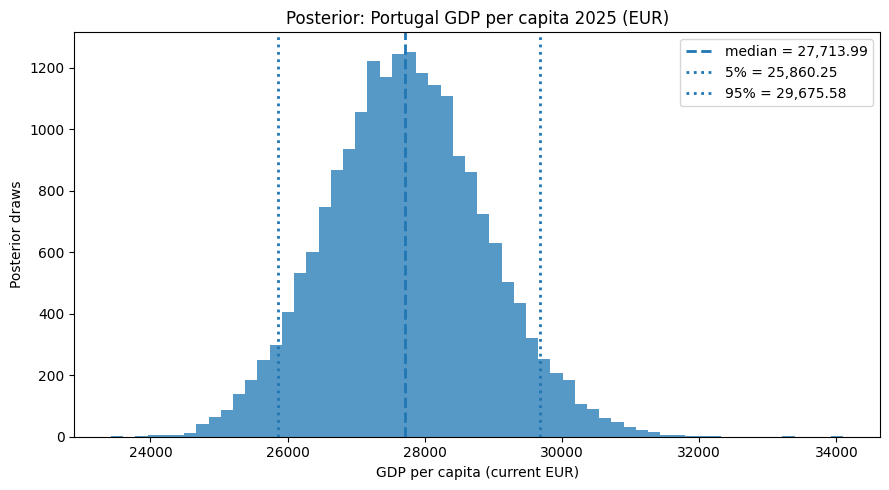

In [12]:
plot_posterior_histogram(gdp_pc_samples,
                         title="Posterior: Portugal GDP per capita 2025 (EUR)",
                         xlabel="GDP per capita (current EUR)")

## 9. How many of the extra residents actually work? Estimate it from data

The revision implies a number of **extra residents** versus the population used in the
preliminary calculation. Instead of guessing how many work, we estimate it from **observed
migrant labour-market behaviour**:

- **Employment rate of the foreign-born (15-64)** in Portugal — fetched live from the OECD
  International Migration Database. It is currently **~76%**, *higher* than the native-born
  rate: Portuguese immigration is overwhelmingly labour migration.
- **Working-age (15-64) share of migrants** — migrants are far more concentrated in working
  ages than the resident population (~85% vs ~64%); centred at 0.85 with uncertainty.
- **Relative productivity** — migrants cluster in lower-paying sectors, so output per
  migrant worker is taken at ~0.8 of the economy-wide average (a relative-wage proxy), with
  **wide** uncertainty because this is the least pinned-down lever.

Each parameter is **drawn with uncertainty**, so the result is a distribution.

In [13]:
import io
import requests


def _oecd_employment_rate_foreign_born(country="PRT"):
    """Recent foreign-born employment rate (15-64, share) from the OECD migration database."""
    url = ("https://sdmx.oecd.org/public/rest/data/OECD.ELS.IMD,DSD_MIG@DF_MIG_EMP_EDU,/"
           ".......?startPeriod=2022&format=csvfilewithlabels&dimensionAtObservation=AllDimensions")
    raw = pd.read_csv(io.StringIO(
        requests.get(url, timeout=90, headers={"User-Agent": "pt-gdp-bayes/1.0"}).text))
    fb = raw[(raw["REF_AREA"] == country)
             & (raw["Place of birth"].str.contains("Foreign", na=False))
             & (raw["SEX"] == "_T") & (raw["Education level"] == "Total")]
    return float(fb["OBS_VALUE"].mean()) / 100.0


migrant_employment_rate = _oecd_employment_rate_foreign_born()   # employed / working-age pop
print(f"OECD foreign-born employment rate, Portugal (2022-24 mean): {migrant_employment_rate:.1%}")

old_population_basis_2025 = revised_population_2025 / population_correction_factor
extra_residents_2025 = revised_population_2025 - old_population_basis_2025

labour_baseline = (panel.dropna(subset=["labor_force", "unemployment_pct", "gdp_current_eur"])
                   .sort_values("year").iloc[-1])
baseline_employed = labour_baseline["labor_force"] * (1.0 - labour_baseline["unemployment_pct"] / 100.0)
baseline_output_per_employed = labour_baseline["gdp_current_eur"] / baseline_employed

pd.Series({
    "implied_extra_residents": extra_residents_2025,
    "migrant_employment_rate_15_64": migrant_employment_rate,
    "baseline_year": int(labour_baseline["year"]),
    "baseline_output_per_employed_eur": baseline_output_per_employed,
}).round(3)

OECD foreign-born employment rate, Portugal (2022-24 mean): 76.5%


implied_extra_residents             605819.826
migrant_employment_rate_15_64            0.765
baseline_year                         2024.000
baseline_output_per_employed_eur     56796.185
dtype: float64

In [14]:
# Data-grounded central case, plus a lower and an upper bound. participation x employment is
# decomposed so their product equals the observed foreign-born employment rate (no double count).
central_activity = 0.87                                   # foreign-born activity rate
central_emp_given_active = migrant_employment_rate / central_activity

SCENARIOS = pd.DataFrame([
    {"scenario": "Denominator only (lower bound)",
     "working_age_share": 0.00, "participation_rate": 0.00,
     "employment_rate": 0.00, "productivity_relative": 0.00},
    {"scenario": "Data-grounded central",
     "working_age_share": 0.85, "participation_rate": central_activity,
     "employment_rate": central_emp_given_active, "productivity_relative": 0.80},
    {"scenario": "Full-absorption (upper bound)",
     "working_age_share": 0.92, "participation_rate": 0.90,
     "employment_rate": 0.95, "productivity_relative": 1.00},
])

base_pps_index_samples = estimate_pps_index_samples(
    preliminary_index=preliminary_pps_index,
    population_correction_factor=population_correction_factor,
    n_samples=20_000, random_seed=17,
)

labour_rng = np.random.default_rng(31)
scenario_rows, scenario_sample_map = [], {}
for row in SCENARIOS.itertuples(index=False):
    extra_gdp_samples = simulate_labour_channel_samples(
        extra_residents=extra_residents_2025,
        baseline_output_per_employed=baseline_output_per_employed,
        working_age_share=row.working_age_share, participation_rate=row.participation_rate,
        employment_rate=row.employment_rate, productivity_relative=row.productivity_relative,
        n_samples=20_000, rng=labour_rng,
    )
    scenario_gdp_samples = gdp_result.gdp_samples + extra_gdp_samples
    scenario_pps_samples = base_pps_index_samples * (scenario_gdp_samples / gdp_result.gdp_samples)
    scenario_sample_map[row.scenario] = {
        "gdp_pc": scenario_gdp_samples / population_result.samples, "pps": scenario_pps_samples}
    gpc = summarize_samples(scenario_gdp_samples / population_result.samples)
    pps = summarize_samples(scenario_pps_samples)
    scenario_rows.append({
        "scenario": row.scenario,
        "extra_gdp_bn_eur": extra_gdp_samples.mean() / 1e9,
        "gdp_pc_median_eur": gpc["median"],
        "pps_median": pps["median"], "pps_q5": pps["q5"], "pps_q95": pps["q95"],
    })

scenario_summary = pd.DataFrame(scenario_rows)
scenario_summary.round(2)

,scenario,extra_gdp_bn_eur,gdp_pc_median_eur,pps_median,pps_q5,pps_q95
0,Denominator only (lower bound),0.00,27713.99,76.99,76.34,77.64
1,Data-grounded central,17.55,29259.06,81.21,79.61,83.15
2,Full-absorption (upper bound),25.60,29956.76,83.18,81.04,85.60


**Reading this table.** `extra_gdp_bn_eur` is the mean extra output (billion EUR) the extra
residents add; `pps_median` with its 90% interval (`pps_q5`-`pps_q95`) is the
GDP-per-capita-in-PPS index (EU = 100). The **data-grounded central** row is the headline
estimate; "Denominator only" (no output from the extra residents) is the pessimistic bound
the article uses, and "Full-absorption" is the optimistic bound.

### The headline: the data-grounded central estimate

In [15]:
central = scenario_summary.loc[scenario_summary["scenario"] == "Data-grounded central"].iloc[0]
denom = scenario_summary.loc[scenario_summary["scenario"].str.startswith("Denominator")].iloc[0]
article_pps = get_known_value(known_observations, "article_corrected_gdp_pc_pps_index", 2025)

print(f"DATA-GROUNDED CENTRAL GDP per capita in PPS: {central['pps_median']:.1f} "
      f"(90% interval {central['pps_q5']:.1f}-{central['pps_q95']:.1f}, EU = 100)")
print(f"  preliminary = {preliminary_pps_index:.1f}   |   "
      f"denominator-only / article worst case = {article_pps:.1f}")
print(f"\nBecause migrants work at ~{migrant_employment_rate:.0%}, the extra residents add about "
      f"{central['extra_gdp_bn_eur']:.0f} bn EUR of output, recovering most of the mechanical "
      f"loss. The denominator-only {denom['pps_median']:.0f} is a worst case, not the estimate.")

DATA-GROUNDED CENTRAL GDP per capita in PPS: 81.2 (90% interval 79.6-83.1, EU = 100)
  preliminary = 81.3   |   denominator-only / article worst case = 77.0

Because migrants work at ~76%, the extra residents add about 18 bn EUR of output, recovering most of the mechanical loss. The denominator-only 77 is a worst case, not the estimate.


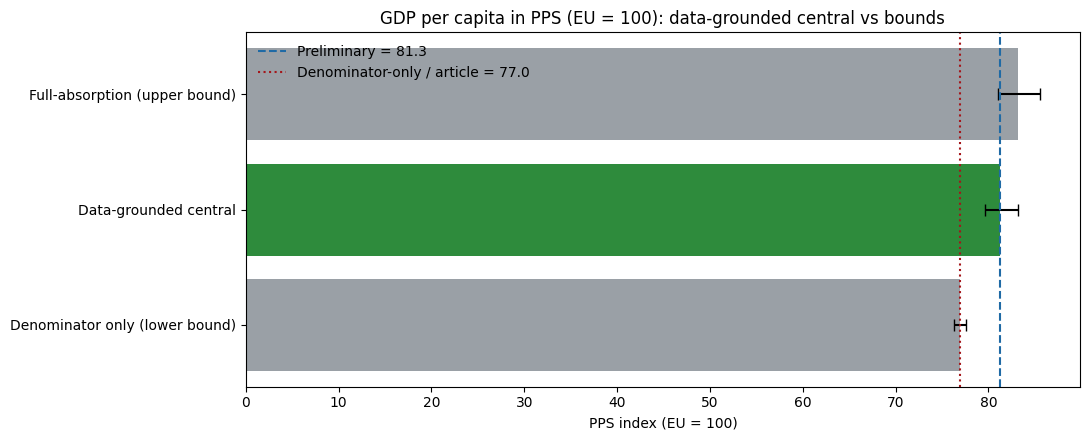

In [16]:
fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["#9aa0a6", "#2E8B3C", "#9aa0a6"]
y = np.arange(len(scenario_summary))
ax.barh(y, scenario_summary["pps_median"], color=colors,
        xerr=[scenario_summary["pps_median"] - scenario_summary["pps_q5"],
              scenario_summary["pps_q95"] - scenario_summary["pps_median"]], capsize=4)
ax.axvline(preliminary_pps_index, color="#1f6aa5", ls="--",
           label=f"Preliminary = {preliminary_pps_index:.1f}")
ax.axvline(article_pps, color="#A4161A", ls=":",
           label=f"Denominator-only / article = {article_pps:.1f}")
ax.set_yticks(y); ax.set_yticklabels(scenario_summary["scenario"])
ax.set(title="GDP per capita in PPS (EU = 100): data-grounded central vs bounds",
       xlabel="PPS index (EU = 100)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

The data changes the conclusion. Because Portugal's migrants are overwhelmingly working-age
and employed at a rate **higher** than natives, the **central, data-grounded** estimate sits
close to the preliminary level — **not** at the denominator-only floor near 77. The
denominator-only figure is a worst case (zero output from the extra residents) that the
labour-market data does not support.

## 10. GDP per capita in PPS: sensitivity layer

The transparent sensitivity block generalises the mechanical correction
`corrected = preliminary / population_correction_factor` by letting GDP and the EU reference
average move as uncertain quantities (here without the labour channel, to isolate the
denominator effect).

In [17]:
pps_index_samples = estimate_pps_index_samples(
    preliminary_index=preliminary_pps_index,
    population_correction_factor=population_correction_factor,
    n_samples=20_000, random_seed=17,
)
mechanical_index = preliminary_pps_index / population_correction_factor
print(f"Preliminary index:                {preliminary_pps_index:.2f}")
print(f"Mechanical denominator-only index: {mechanical_index:.2f}")
summarise(pps_index_samples, decimals=2, label="GDP pc in PPS (EU=100)")

Preliminary index:                81.30
Mechanical denominator-only index: 76.99


,GDP pc in PPS (EU=100)
mean,76.99
median,76.99
sd,0.39
q5,76.34
q95,77.64


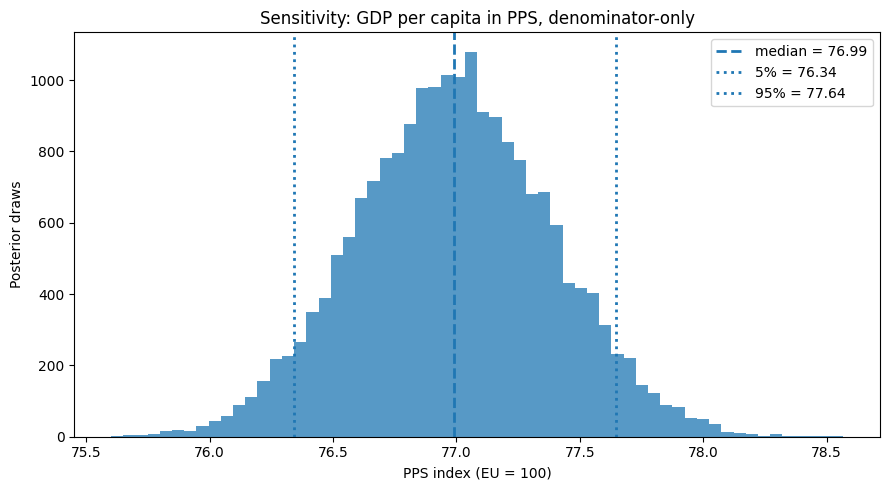

In [18]:
plot_posterior_histogram(pps_index_samples,
                         title="Sensitivity: GDP per capita in PPS, denominator-only",
                         xlabel="PPS index (EU = 100)")

## 11. Summary

The quantity the public argument is about is the **GDP-per-capita-in-PPS index (EU = 100)**.
We lead with the **data-grounded central** estimate (migrants employed at the observed ~76%
rate), then show the denominator-only worst case and the full-absorption best case as bounds.
Euro figures are exact; USD numbers are kept out of the headline because they carry euro/dollar
noise.

In [19]:
def _fmt(samples, scale, unit, dec):
    s = summarize_samples(samples)
    return {k: f"{s[k] / scale:,.{dec}f}{unit}" for k in ["median", "mean", "sd", "q5", "q95"]}

summary = pd.DataFrame({
    "GDP pc in PPS - DATA-GROUNDED CENTRAL (EU=100)":
        _fmt(scenario_sample_map["Data-grounded central"]["pps"], 1, "", 2),
    "GDP pc in PPS - denominator-only worst case (EU=100)":
        _fmt(scenario_sample_map["Denominator only (lower bound)"]["pps"], 1, "", 2),
    "GDP pc in PPS - full-absorption best case (EU=100)":
        _fmt(scenario_sample_map["Full-absorption (upper bound)"]["pps"], 1, "", 2),
    "Population 2025 (millions)": _fmt(population_result.samples, 1e6, "", 3),
    "GDP 2025 (billion EUR)": _fmt(gdp_result.gdp_samples, 1e9, "", 1),
    "GDP per capita 2025, denominator basis (EUR)": _fmt(gdp_pc_samples, 1, "", 0),
}).T
summary.columns = ["median", "mean", "sd", "5%", "95%"]
summary

,median,mean,sd,5%,95%
GDP pc in PPS - DATA-GROUNDED CENTRAL (EU=100),81.21,81.27,1.08,79.61,83.15
GDP pc in PPS - denominator-only worst case (EU=100),76.99,76.99,0.39,76.34,77.64
GDP pc in PPS - full-absorption best case (EU=100),83.18,83.24,1.38,81.04,85.60
Population 2025 (millions),11.398,11.398,0.017,11.371,11.426
GDP 2025 (billion EUR),315.9,316.1,13.1,294.7,338.3
"GDP per capita 2025, denominator basis (EUR)","27,714","27,733","1,152","25,860","29,676"


## 12. Interpretation

The headline is the **data-grounded central** estimate, not the worst case. Anchoring the
labour absorption to the **observed** foreign-born employment rate (~76%, higher than
natives), Portugal's 2025 GDP per capita in PPS lands **close to the preliminary level**,
with a credible interval — well above the denominator-only floor near 77.

> The revised population does **not** mechanically lower Portugal's GDP per capita. Because
> the extra residents are overwhelmingly working-age and employed at a high rate, they add
> output roughly in proportion to the headcount. The denominator-only correction (~77) is the
> pessimistic bound — what would happen if the extra residents produced nothing — and the
> data does not support it.

- the article-style correction (~**77**) is the **lower bound**, not the estimate;
- the data-grounded central estimate sits near the preliminary level;
- only an implausibly low migrant-productivity assumption pushes it back toward 77.

So the real question — "what fraction of the revised population is economically productive?" —
is answered **from data**, not assumed: about three-quarters of working-age migrants are
employed, so most of the headcount also shows up in output.

**Caveats.** The employment rate is observed; the working-age share (~0.85) and relative
productivity (~0.80) are anchored to migrant demographics and the migrant-native wage gap and
carried with uncertainty (productivity is the widest lever). The population posterior is
anchored to the revised INE figure; all series are annual; and the back-test shows the GDP
model is well calibrated outside crisis years — the regime this 2025 estimate sits in.